# 02 - Analisis exploratorio

Distribuciones univariadas, churn rate por segmento, y las dos anomalias de calidad de datos que hay que resolver antes de modelar: `Monthly_Charge` negativo y nulos estructurales en las columnas de servicio.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

DATA_PATH = "../data/Customer_Data.csv"
TARGET_COL = "Customer_Status"
MONTHLY_CHARGE_COL = "Monthly_Charge"
INTERNET_DEPENDENT_COLS = [
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
]

df = pd.read_csv(DATA_PATH)
df_model = df[df[TARGET_COL].isin(["Stayed", "Churned"])].copy()
df_joined = df[df[TARGET_COL] == "Joined"].copy()

## Variables numericas (df_model)

In [2]:
numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months",
    "Monthly_Charge", "Total_Charges", "Total_Revenue",
]
df_model[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6007.0,47.289163,16.805110,18.00,33.000,47.00,60.000,84.00
Number_of_Referrals,6007.0,7.439820,4.622369,0.00,3.000,7.00,11.000,15.00
Tenure_in_Months,6007.0,17.394540,10.592920,1.00,8.000,17.00,27.000,36.00
Monthly_Charge,6007.0,65.087598,31.067808,-10.00,35.950,71.10,90.450,118.75
Total_Charges,6007.0,2430.986173,2267.481294,19.10,539.950,1556.85,4013.900,8684.80
Total_Revenue,6007.0,3233.246021,2856.181082,21.61,833.685,2367.15,5105.685,11979.34


## Churn rate por segmento

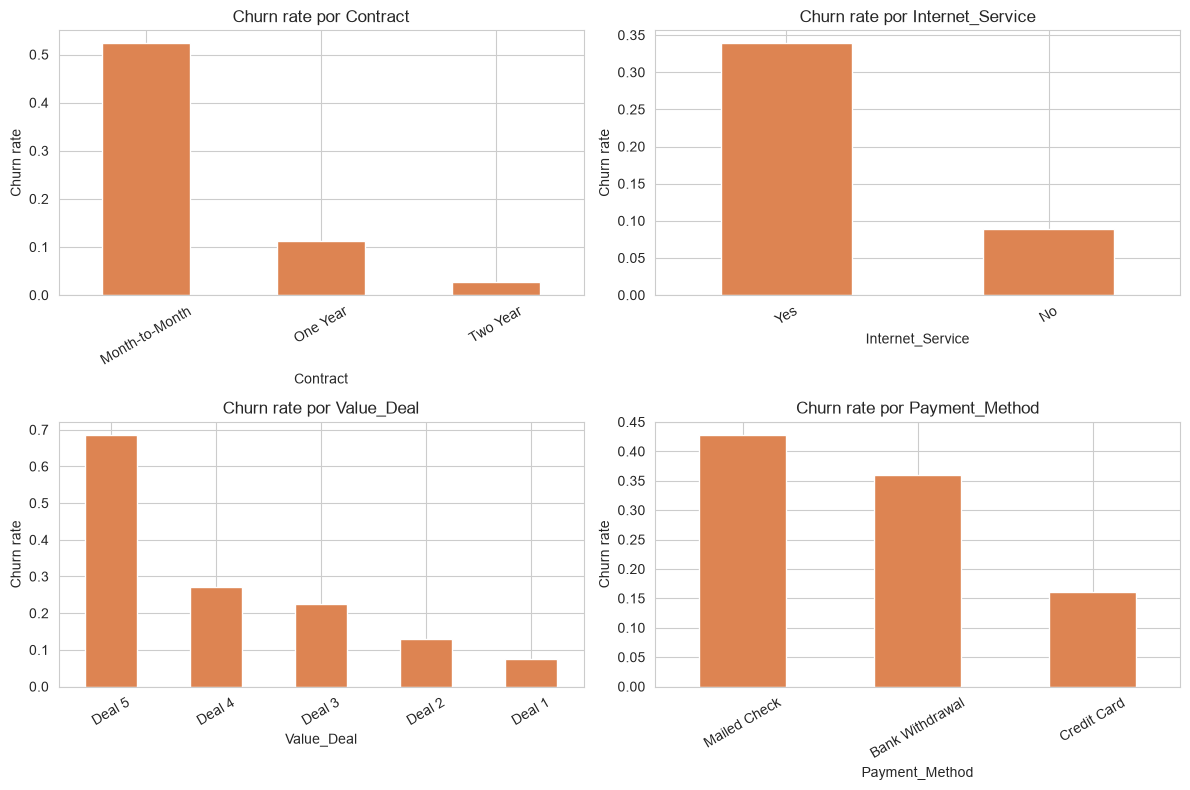

In [3]:
segment_cols = ["Contract", "Internet_Service", "Value_Deal", "Payment_Method"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, segment_cols):
    churn_rate = (
        df_model.groupby(col)[TARGET_COL]
        .apply(lambda s: (s == "Churned").mean())
        .sort_values(ascending=False)
    )
    churn_rate.plot(kind="bar", ax=ax, color="#DD8452")
    ax.set_title(f"Churn rate por {col}")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Anomalia: `Monthly_Charge` negativo

107 filas (1.7%) tienen `Monthly_Charge` negativo, entre -1 y -10, todas enteras -- un patron que apunta a valores sinteticos/sucios, no a cobros reales. Se excluyen antes de modelar.

In [4]:
negative_mask = df[MONTHLY_CHARGE_COL] < 0
print(f"Filas con Monthly_Charge negativo: {negative_mask.sum()} ({negative_mask.mean():.1%})")
df.loc[negative_mask, MONTHLY_CHARGE_COL].value_counts().sort_index()

Filas con Monthly_Charge negativo: 107 (1.7%)


Monthly_Charge
-10.0    12
-9.0      8
-8.0     12
-7.0     14
-6.0      5
-5.0     11
-4.0     14
-3.0     11
-2.0     10
-1.0     10
Name: count, dtype: int64

## Anomalia: nulos estructurales en columnas de servicio

Las columnas dependientes de internet estan vacias unicamente cuando el cliente no tiene `Internet_Service` -- no es informacion faltante al azar.

In [5]:
internet_no = df_model["Internet_Service"] == "No"

print("Tasa de nulos SIN internet:")
print(df_model.loc[internet_no, INTERNET_DEPENDENT_COLS].isna().mean())

print("\nTasa de nulos CON internet (debe ser ~0):")
print(df_model.loc[~internet_no, INTERNET_DEPENDENT_COLS].isna().mean())

Tasa de nulos SIN internet:
Internet_Type             1.0
Online_Security           1.0
Online_Backup             1.0
Device_Protection_Plan    1.0
Premium_Support           1.0
Streaming_TV              1.0
Streaming_Movies          1.0
Streaming_Music           1.0
Unlimited_Data            1.0
dtype: float64

Tasa de nulos CON internet (debe ser ~0):
Internet_Type             0.0
Online_Security           0.0
Online_Backup             0.0
Device_Protection_Plan    0.0
Premium_Support           0.0
Streaming_TV              0.0
Streaming_Movies          0.0
Streaming_Music           0.0
Unlimited_Data            0.0
dtype: float64


## Distribuciones numericas por churn

`Monthly_Charge` se filtra a >= 0 para esta comparacion (ver anomalia arriba); el resto de columnas no tiene esa distorsion.

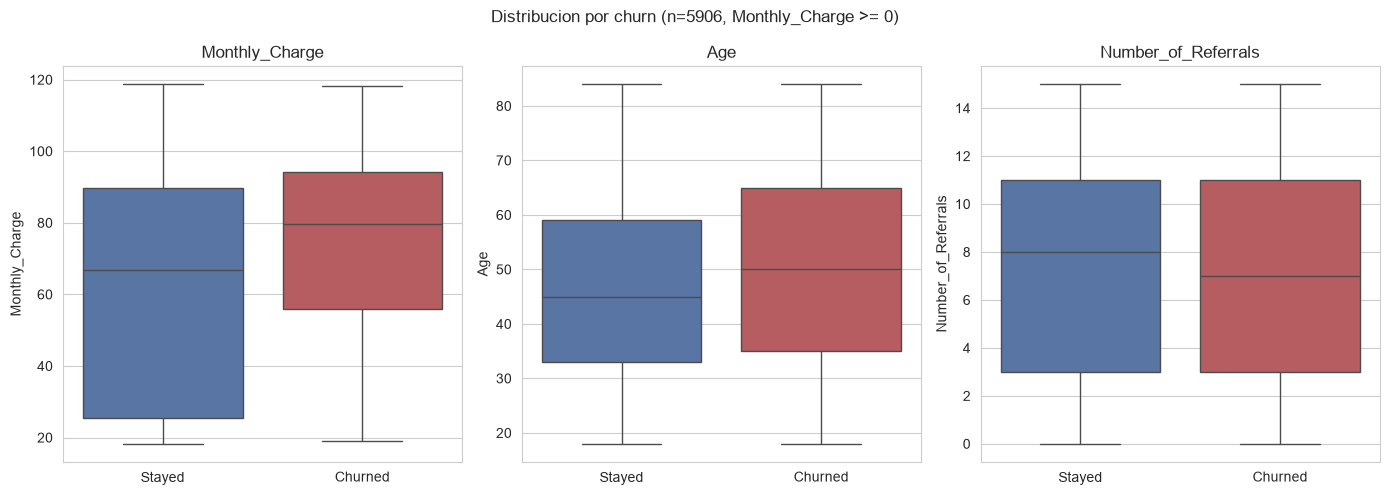

In [6]:
df_clean = df_model[df_model[MONTHLY_CHARGE_COL] >= 0].copy()
df_clean["churn_flag"] = (df_clean[TARGET_COL] == "Churned").astype(int)

box_cols = [MONTHLY_CHARGE_COL, "Age", "Number_of_Referrals"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df_clean, x=TARGET_COL, y=col, hue=TARGET_COL, palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle(f"Distribucion por churn (n={len(df_clean)}, Monthly_Charge >= 0)")
plt.tight_layout()
plt.show()

## Correlacion de variables numericas

Matriz de correlacion Pearson entre las variables numericas y `churn_flag` (1 = Churned), sobre `df_clean`.

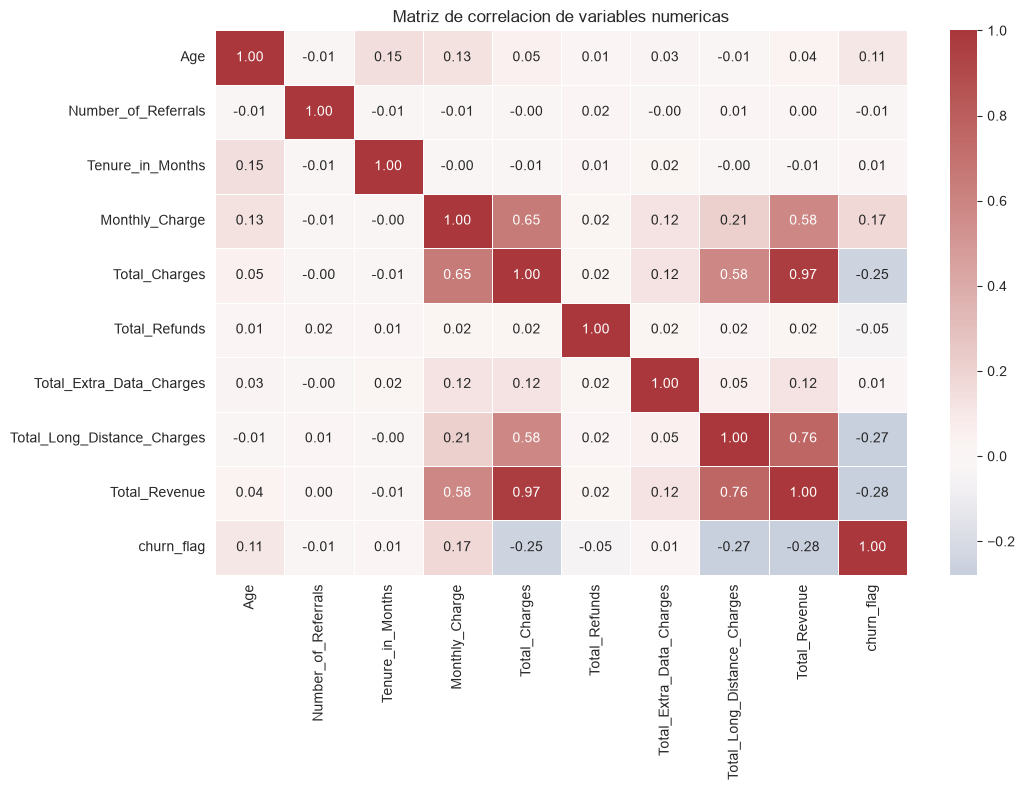

In [7]:
full_numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months", "Monthly_Charge",
    "Total_Charges", "Total_Refunds", "Total_Extra_Data_Charges",
    "Total_Long_Distance_Charges", "Total_Revenue", "churn_flag",
]
corr_matrix = df_clean[full_numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Matriz de correlacion de variables numericas")
plt.tight_layout()
plt.show()

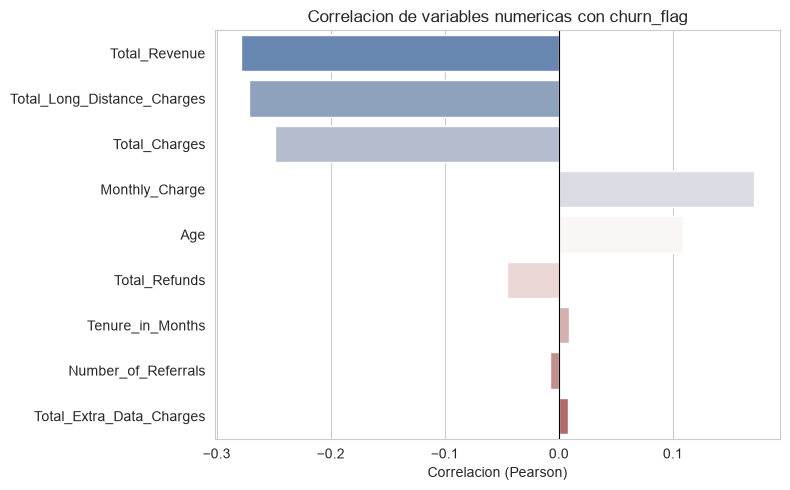

Total_Revenue                 -0.278804
Total_Long_Distance_Charges   -0.271306
Total_Charges                 -0.249086
Monthly_Charge                 0.171366
Age                            0.109168
Total_Refunds                 -0.045327
Tenure_in_Months               0.008592
Number_of_Referrals           -0.008000
Total_Extra_Data_Charges       0.007897
Name: churn_flag, dtype: float64

In [8]:
target_corr = corr_matrix["churn_flag"].drop("churn_flag").sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlacion de variables numericas con churn_flag")
plt.xlabel("Correlacion (Pearson)")
plt.ylabel("")
plt.tight_layout()
plt.show()
target_corr

## Asociacion de variables categoricas con churn (Cramer's V)

Los nulos estructurales de las columnas dependientes de internet (y `Value_Deal`) se imputan con una categoria explicita antes de medir asociacion -- eliminarlos sesgaria el calculo hacia el ~80% de clientes que si tiene el servicio.

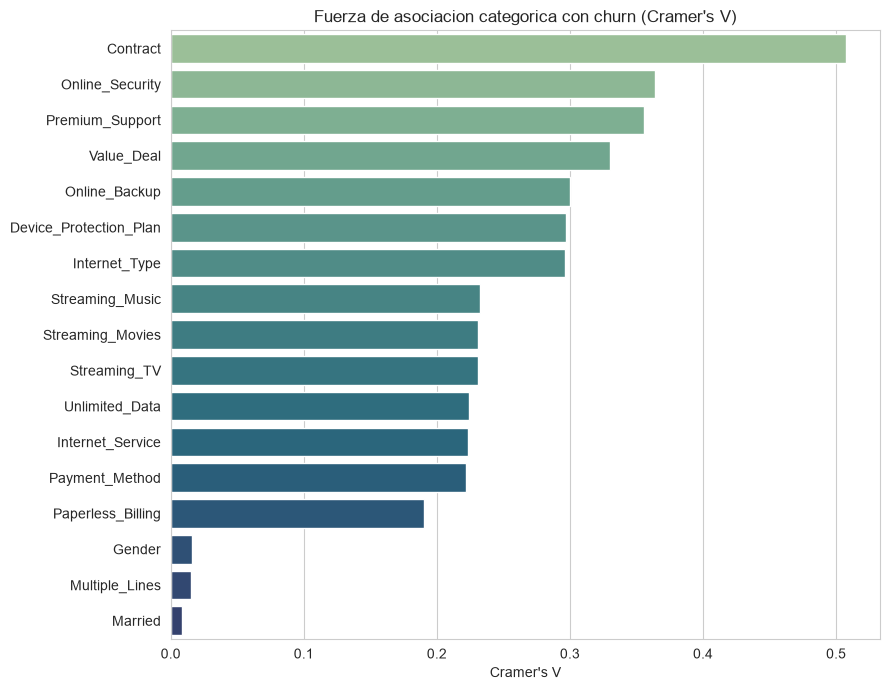

Contract                  0.507596
Online_Security           0.364002
Premium_Support           0.355460
Value_Deal                0.330278
Online_Backup             0.299758
Device_Protection_Plan    0.297311
Internet_Type             0.296477
Streaming_Music           0.232598
Streaming_Movies          0.230847
Streaming_TV              0.230656
Unlimited_Data            0.224165
Internet_Service          0.223465
Payment_Method            0.221944
Paperless_Billing         0.189989
Gender                    0.015871
Multiple_Lines            0.014880
Married                   0.008794
dtype: float64

In [9]:
import numpy as np


def cramers_v(x, y):
    table = pd.crosstab(x, y)
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / n
    chi2_stat = np.divide(
        (observed - expected) ** 2, expected,
        out=np.zeros_like(observed), where=expected > 0,
    ).sum()
    r, k = observed.shape
    return np.sqrt((chi2_stat / n) / max(1, min(k - 1, r - 1)))


categorical_cols = [
    "Contract", "Internet_Service", "Payment_Method", "Value_Deal",
    "Married", "Paperless_Billing", "Gender", "Multiple_Lines",
] + INTERNET_DEPENDENT_COLS

df_cat = df_clean.copy()
for col in INTERNET_DEPENDENT_COLS:
    df_cat[col] = df_cat[col].fillna("No Internet Service")
df_cat["Multiple_Lines"] = df_cat["Multiple_Lines"].fillna("No Phone Service")
df_cat["Value_Deal"] = df_cat["Value_Deal"].fillna("No Deal")

assoc = pd.Series(
    {col: cramers_v(df_cat[col], df_cat[TARGET_COL]) for col in categorical_cols}
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=assoc.values, y=assoc.index, hue=assoc.index, palette="crest", legend=False)
plt.title("Fuerza de asociacion categorica con churn (Cramer's V)")
plt.xlabel("Cramer's V")
plt.ylabel("")
plt.tight_layout()
plt.show()
assoc

## Resumen

- Los graficos de churn rate por segmento arriba marcan los candidatos a variables predictoras -- se confirman con pruebas de hipotesis en `03_statistical_analysis.ipynb`.
- La matriz de correlacion y el ranking de Cramer's V muestran magnitud de relacion, no solo significancia: `Contract` y `Value_Deal` dominan entre las categoricas; `Total_Revenue`, `Total_Long_Distance_Charges` y `Total_Charges` dominan entre las numericas, pero son acumulados que reflejan antiguedad -- ver advertencia de leakage en `03_statistical_analysis.ipynb` y `04_train_test_split.ipynb`.
- Dos anomalias de datos confirmadas, a resolver en `04_feature_engineering.ipynb`: `Monthly_Charge` negativo (filtrar) y nulos estructurales (imputar con categoria explicita, no eliminar filas).